<a href="https://www.kaggle.com/code/lalit7881/students-at-risk-mental-health-burnout?scriptVersionId=306319301" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sharmajicoder/student-mental-health-and-burnout/student_mental_health_burnout_1M.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sharmajicoder/student-mental-health-and-burnout/student_mental_health_burnout_1M.csv")

In [3]:
df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [4]:
df.tail()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
999995,22,Female,3,5.784771,4.922653,79.292283,2.033221,1.238058,0.000000,8.214062,4.404825,9.013047,1.000000,1.664220,5.374860,4.875184,0.000000,8.815294,Low,0.000000
999996,20,Male,1,3.795347,4.706976,70.718819,4.144918,2.768193,1.405596,6.701671,2.664749,8.678769,2.641657,2.923180,5.100452,5.495558,1.166516,7.089896,Low,0.000000
999997,24,Female,3,8.814898,8.750319,79.121184,4.715533,4.138000,1.931592,6.569535,4.219224,4.881412,5.224459,3.855320,2.290888,6.792472,1.997088,6.292909,Low,1.172209
999998,29,Female,4,5.920859,6.678223,69.424255,5.553155,5.681447,1.366879,8.017232,3.634823,5.232852,2.668379,2.951508,5.885972,6.829679,2.731137,5.664240,Low,1.968401
999999,17,Female,2,5.733588,6.061671,58.666123,2.936770,2.533496,0.661940,6.868650,5.501813,2.832691,1.000000,1.000000,5.187394,5.162718,1.342995,7.866661,Low,0.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-n

In [6]:
df.describe()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,22.996456,2.500782,5.001727,5.998810,70.999135,4.246462,2.986413,1.274728,6.501713,3.011153,4.999724,5.018766,5.038116,5.002920,5.983287,1.784073,7.023073,1.324896
std,3.742579,1.117749,1.989340,1.548268,5.660073,1.678998,1.509844,1.221273,1.472972,1.463679,1.976536,1.960599,2.157838,1.976426,1.960972,1.664035,1.310698,1.342727
min,17.000000,1.000000,0.000000,1.000000,42.365714,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.309745,0.000000
25%,20.000000,2.000000,3.650644,4.944647,67.180912,3.102593,1.923747,0.005198,5.491047,1.990596,3.650029,3.651138,3.491114,3.656767,4.647065,0.124810,6.141553,0.000000
50%,23.000000,3.000000,4.998222,5.998906,70.999914,4.244029,2.969514,1.047839,6.501938,3.000619,4.999017,5.003518,5.001542,5.001279,5.999517,1.496505,7.074414,1.009531
75%,26.000000,4.000000,6.345532,7.051914,74.820937,5.385464,4.014996,2.086397,7.514642,4.011208,6.349751,6.351386,6.506834,6.354571,7.351578,2.889473,7.962169,2.173661
max,29.000000,4.000000,14.000000,10.000000,97.246309,10.000000,10.000000,8.530800,10.000000,7.000000,10.000000,12.000000,14.000000,10.000000,10.000000,10.000000,10.000000,9.326226


In [7]:
df.isnull().sum()

age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

age                       int64
gender                   object
academic_year             int64
study_hours_per_day     float64
exam_pressure           float64
academic_performance    float64
stress_level            float64
anxiety_score           float64
depression_score        float64
sleep_hours             float64
physical_activity       float64
social_support          float64
screen_time             float64
internet_usage          float64
financial_stress        float64
family_expectation      float64
burnout_score           float64
mental_health_index     float64
risk_level               object
dropout_risk            float64
dtype: object

In [10]:
df.shape

(1000000, 20)

In [11]:
df.columns

Index(['age', 'gender', 'academic_year', 'study_hours_per_day',
       'exam_pressure', 'academic_performance', 'stress_level',
       'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'screen_time', 'internet_usage', 'financial_stress',
       'family_expectation', 'burnout_score', 'mental_health_index',
       'risk_level', 'dropout_risk'],
      dtype='object')

In [12]:
df.nunique()

age                          13
gender                        3
academic_year                 4
study_hours_per_day      993775
exam_pressure            994553
academic_performance    1000000
stress_level             993869
anxiety_score            973420
depression_score         751049
sleep_hours              980406
physical_activity        973321
social_support           987746
screen_time              976736
internet_usage           968385
financial_stress         987610
family_expectation       975615
burnout_score            769455
mental_health_index      997359
risk_level                    3
dropout_risk             737663
dtype: int64

## EDA

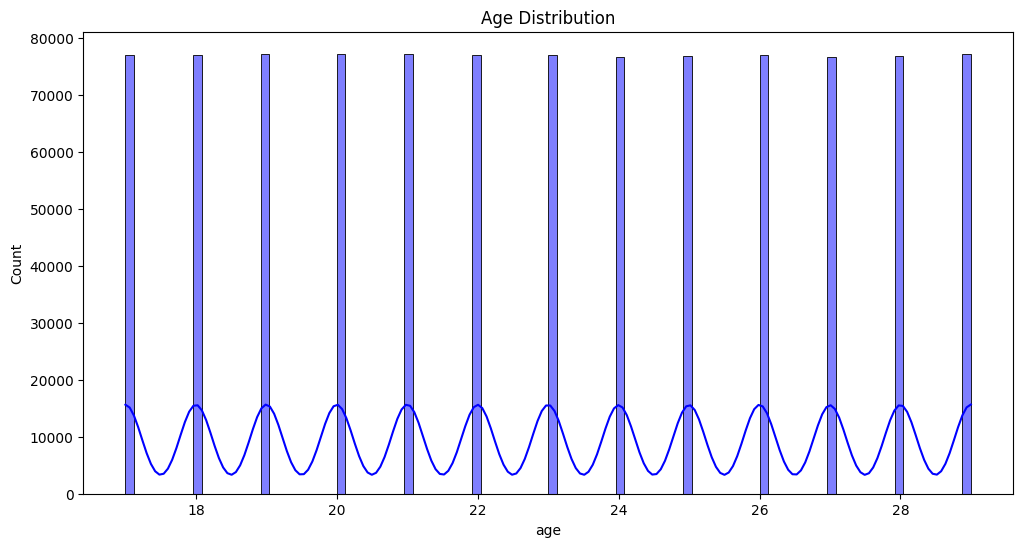

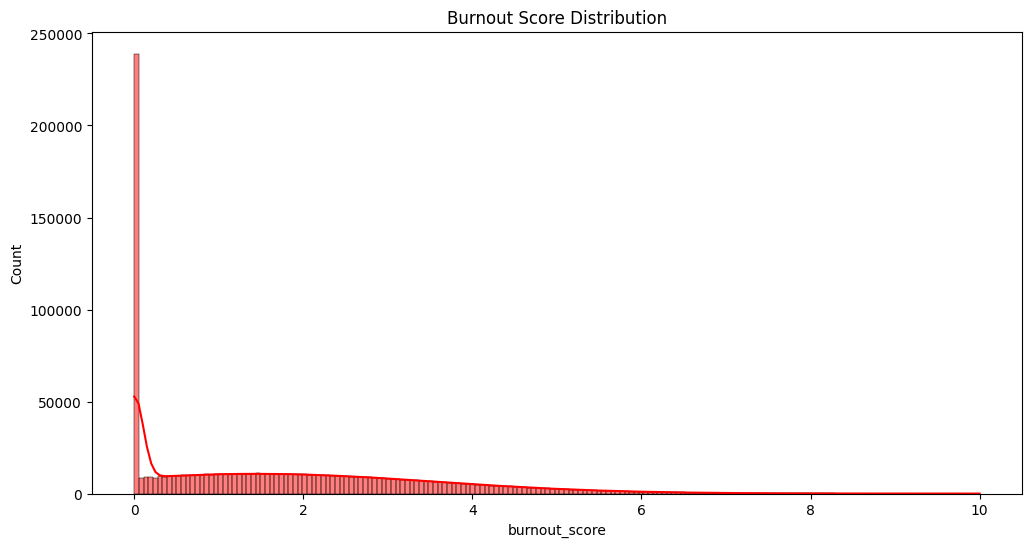

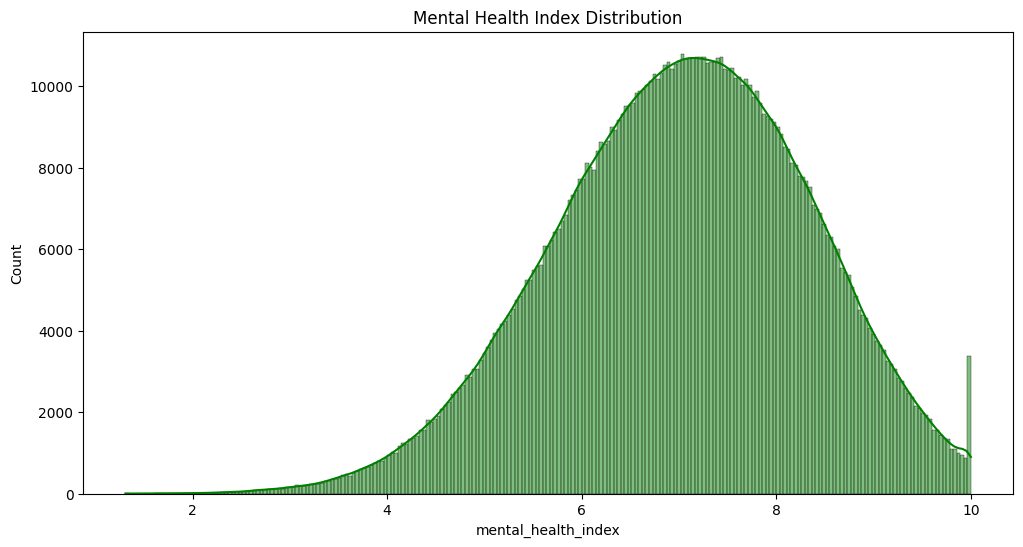

In [13]:
plt.figure(figsize=(12,6))
sns.histplot(df['age'], kde=True, color='blue')
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df['burnout_score'], kde=True, color='red')
plt.title("Burnout Score Distribution")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(df['mental_health_index'], kde=True, color='green')
plt.title("Mental Health Index Distribution")
plt.show()


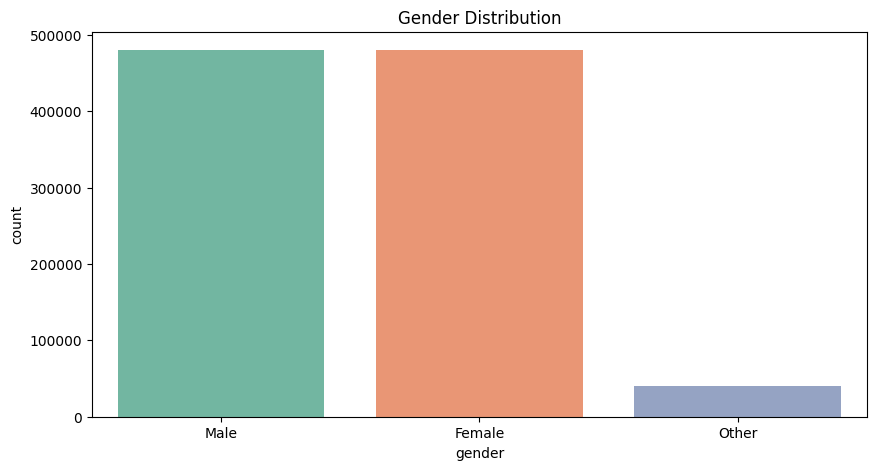

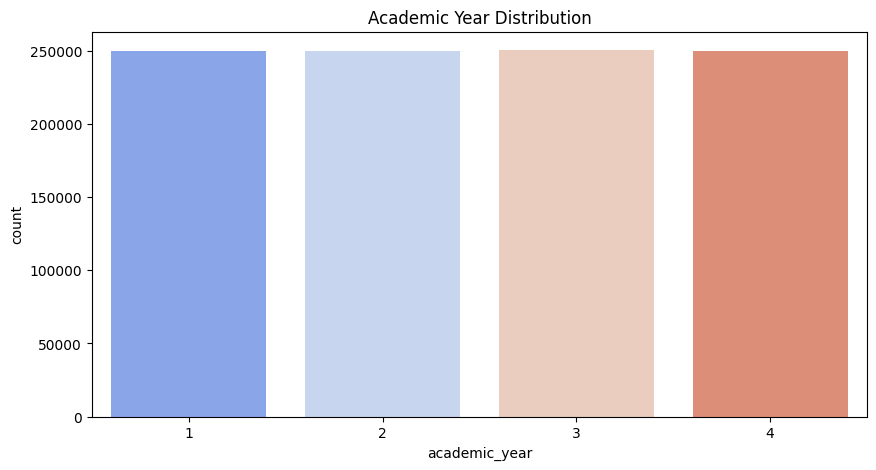

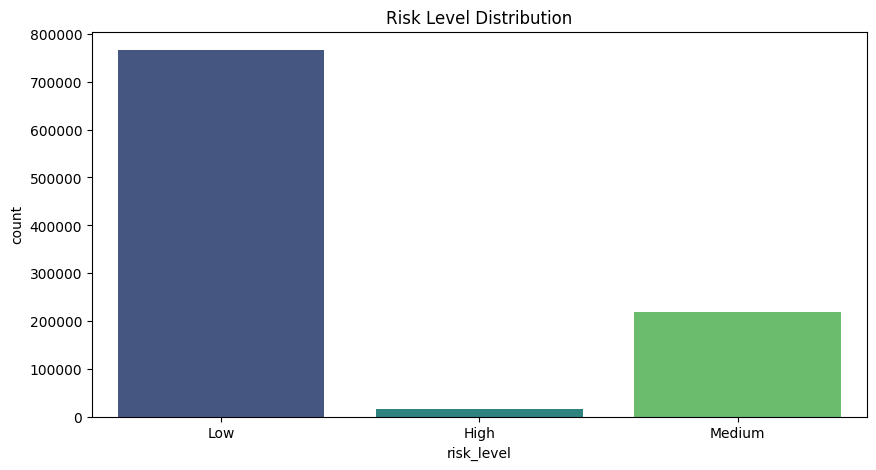

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='academic_year', data=df, palette='coolwarm')
plt.title("Academic Year Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='risk_level', data=df, palette='viridis')
plt.title("Risk Level Distribution")
plt.show()

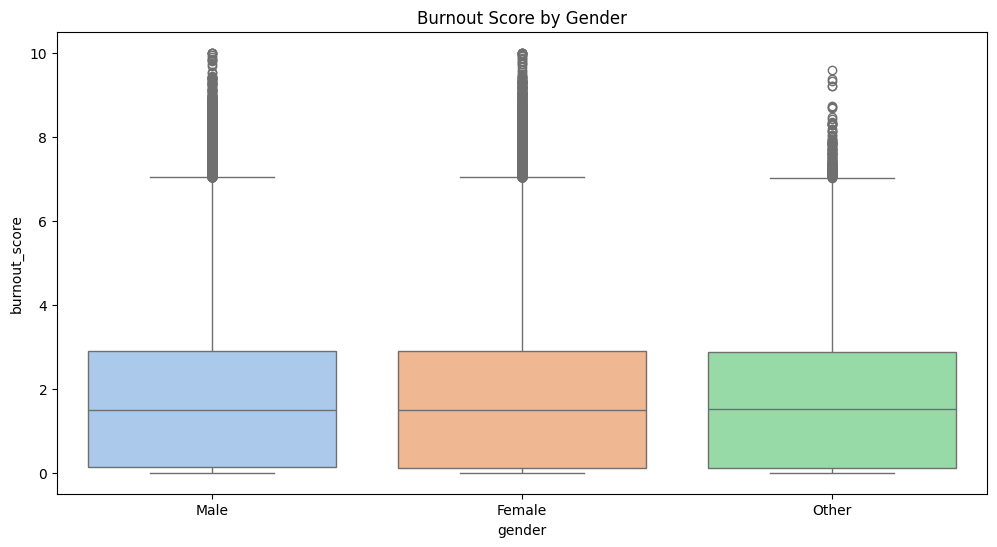

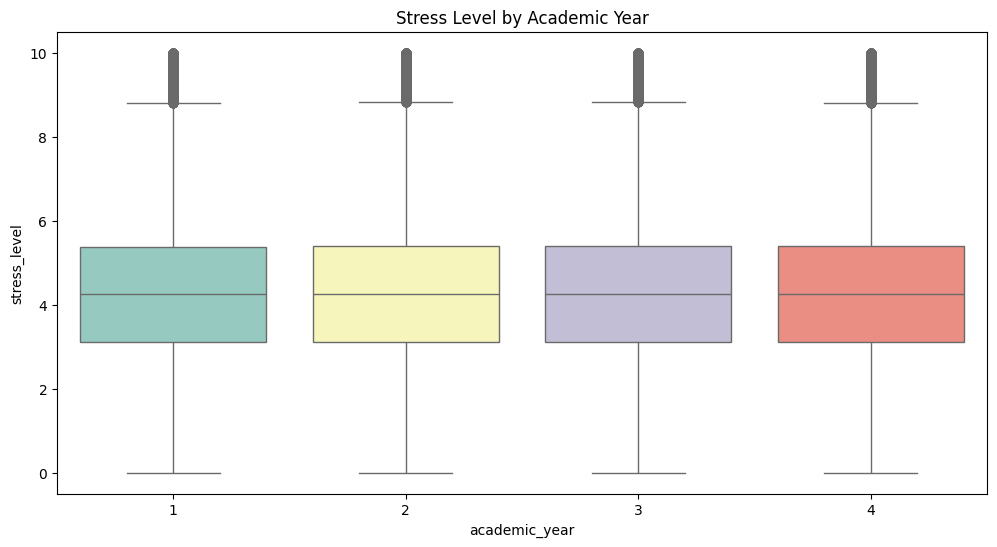

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x='gender', y='burnout_score', data=df, palette='pastel')
plt.title("Burnout Score by Gender")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='academic_year', y='stress_level', data=df, palette='Set3')
plt.title("Stress Level by Academic Year")
plt.show()


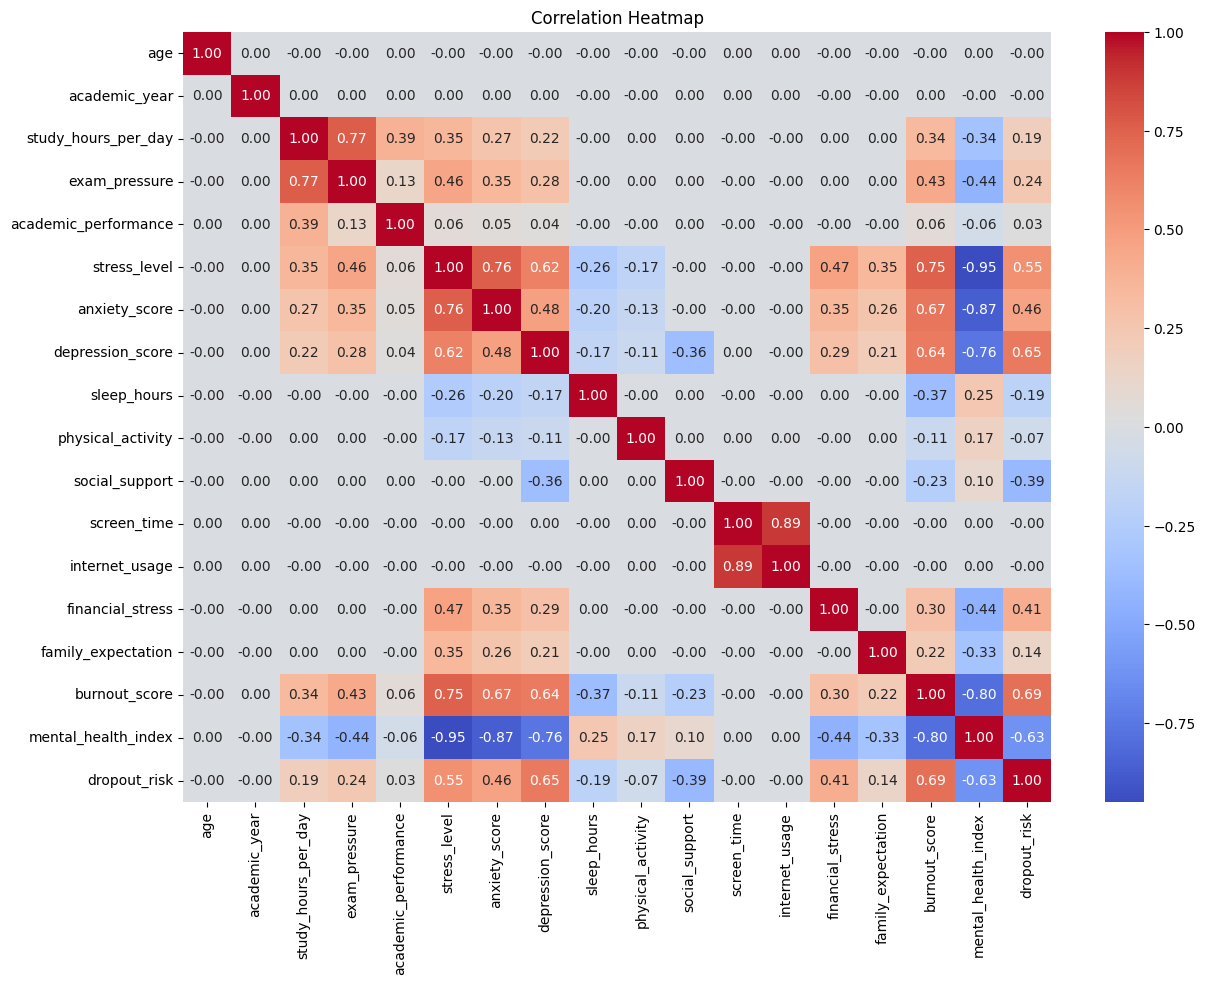

In [16]:
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

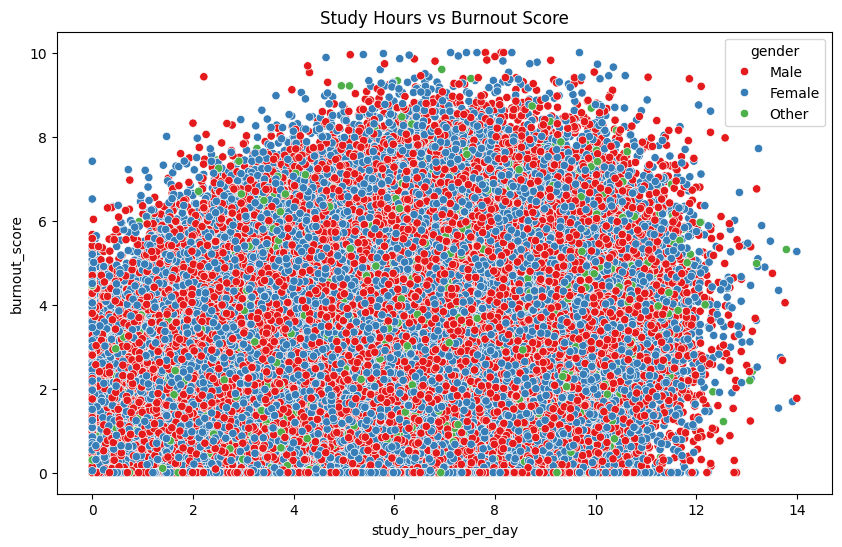

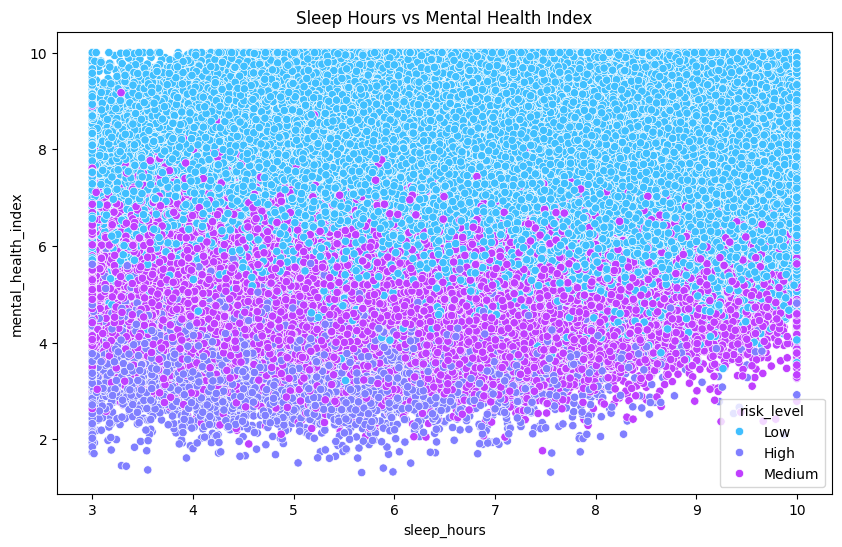

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours_per_day', y='burnout_score',
                hue='gender', palette='Set1', data=df)
plt.title("Study Hours vs Burnout Score")
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x='sleep_hours', y='mental_health_index',
                hue='risk_level', palette='cool', data=df)
plt.title("Sleep Hours vs Mental Health Index")
plt.show()

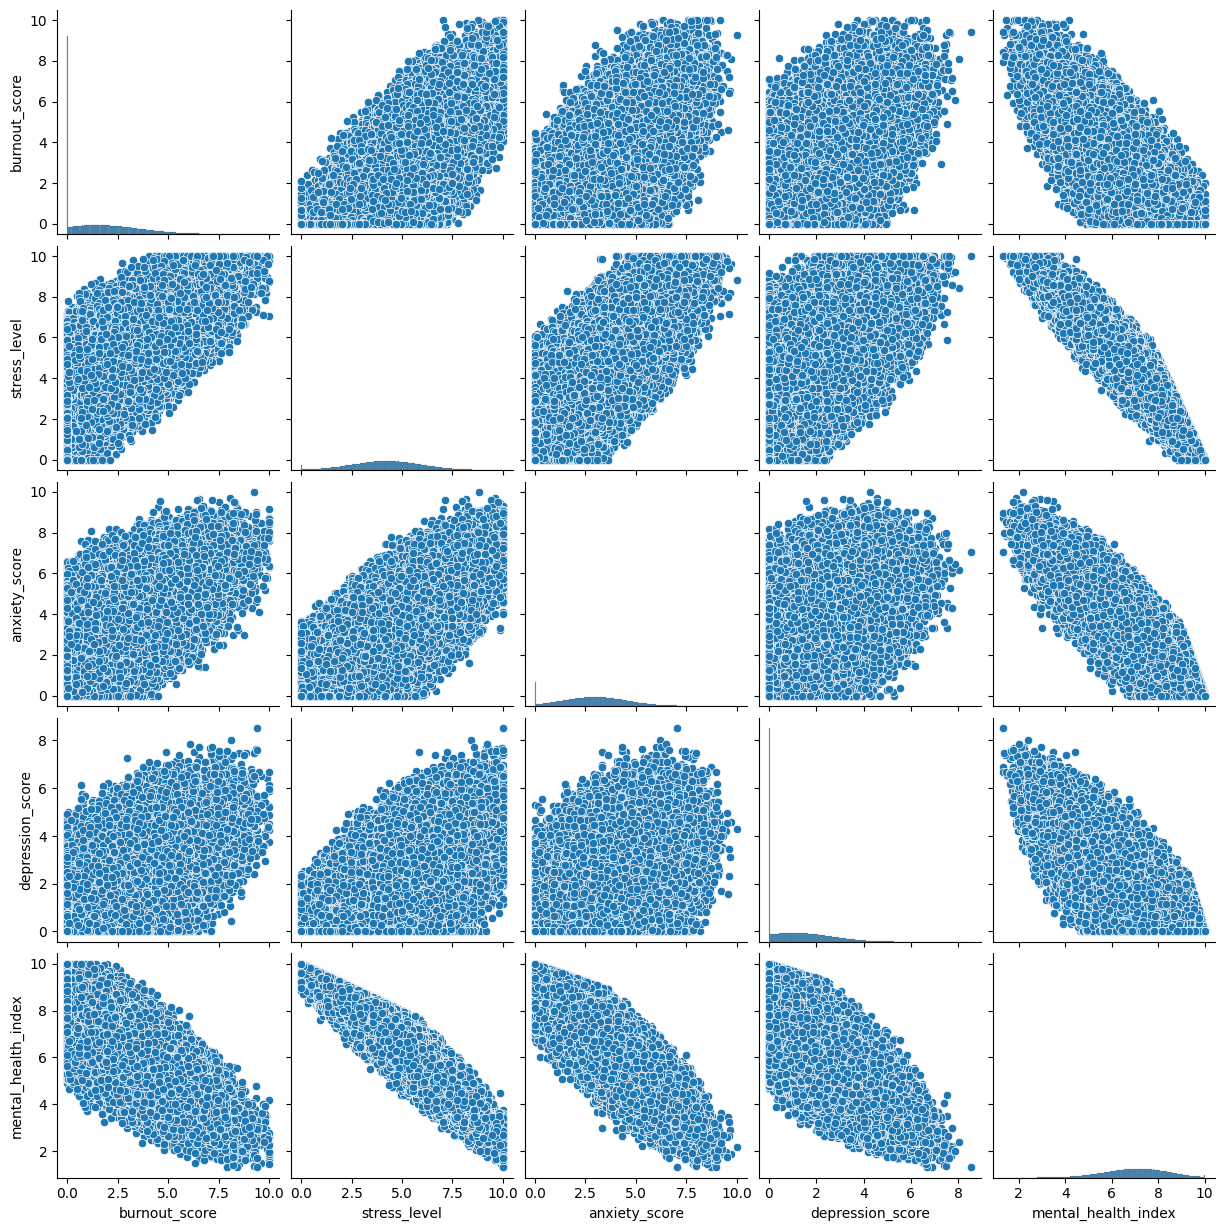

In [18]:
sns.pairplot(df[['burnout_score', 'stress_level',
                 'anxiety_score', 'depression_score',
                 'mental_health_index']],
             palette='husl')
plt.show()

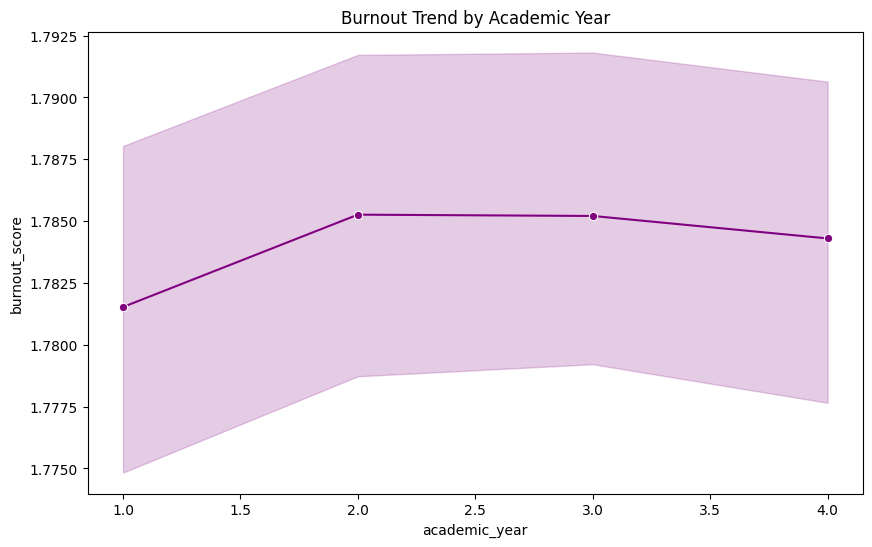

In [19]:
plt.figure(figsize=(10,6))
sns.lineplot(x='academic_year', y='burnout_score',
             data=df, marker='o', color='purple')
plt.title("Burnout Trend by Academic Year")
plt.show()


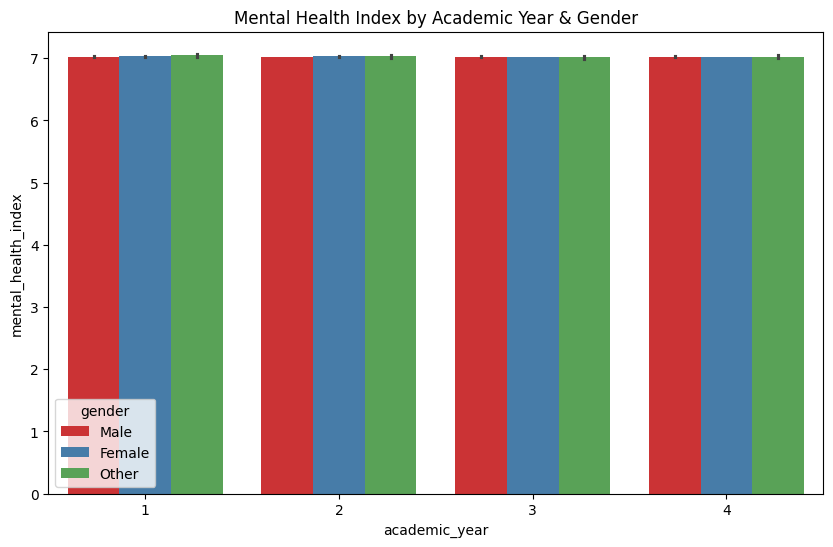

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x='academic_year', y='mental_health_index',
            hue='gender', data=df, palette='Set1')
plt.title("Mental Health Index by Academic Year & Gender")
plt.show()

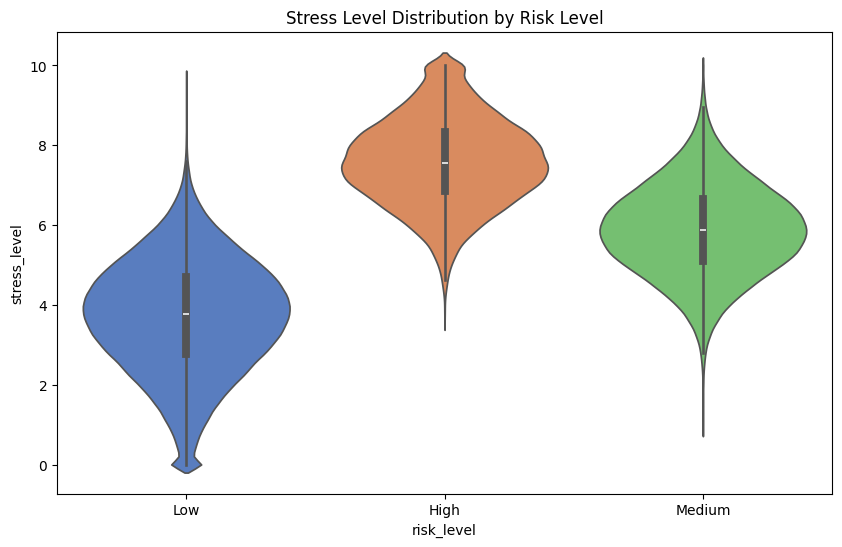

In [21]:
plt.figure(figsize=(10,6))
sns.violinplot(x='risk_level', y='stress_level',
               data=df, palette='muted')
plt.title("Stress Level Distribution by Risk Level")
plt.show()

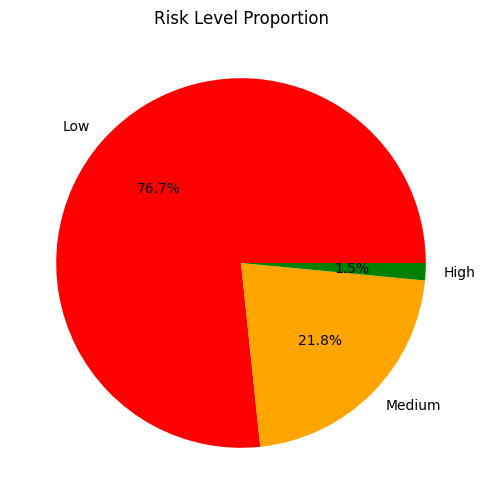

In [22]:
df['risk_level'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['red', 'orange', 'green'],
    figsize=(6,6)
)
plt.title("Risk Level Proportion")
plt.ylabel('')
plt.show()

## Feature engineering

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [24]:
df = df.dropna()

In [25]:
threshold = df['dropout_risk'].median()

df['dropout_risk'] = df['dropout_risk'].apply(
    lambda x: 1 if x > threshold else 0
)

In [26]:
print("Target Distribution:\n", df['dropout_risk'].value_counts())


Target Distribution:
 dropout_risk
1    500000
0    500000
Name: count, dtype: int64


In [27]:
X = df.drop(columns=['dropout_risk'])
y = df['dropout_risk']


In [28]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}


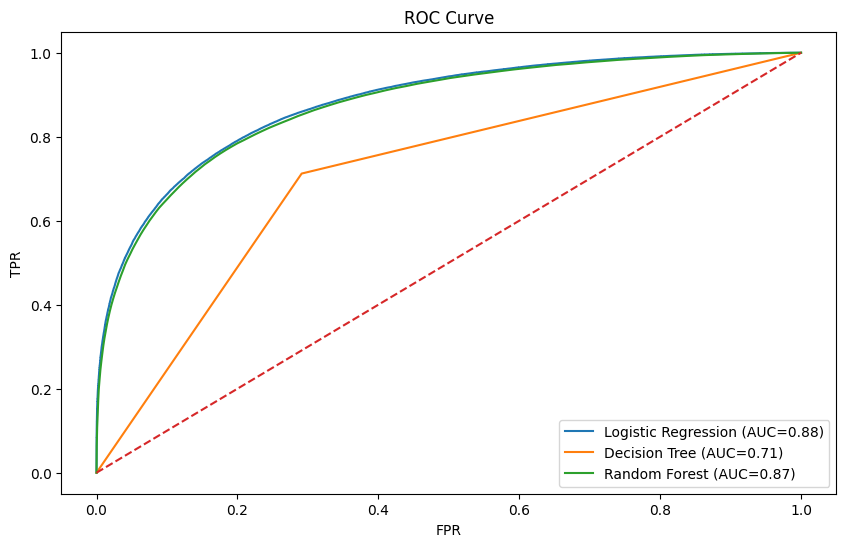

In [32]:
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Create pipeline
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = [acc, auc]
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# Plot ROC
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [33]:
results_df = pd.DataFrame(results, index=["Accuracy", "ROC-AUC"]).T
print(results_df)

                     Accuracy   ROC-AUC
Logistic Regression  0.795215  0.880471
Decision Tree        0.710555  0.710555
Random Forest        0.792415  0.874767


In [34]:
best_model = results_df['ROC-AUC'].idxmax()
print("\nBest Model:", best_model)


Best Model: Logistic Regression


## Thank you...pls upvote!!!!!!!!